### Boston Housing Advanced Regression
https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data


Attribute Information
Input features in order:
1) CRIM: per capita crime rate by town
2) ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3) INDUS: proportion of non-retail business acres per town
4) CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5) NOX: nitric oxides concentration (parts per 10 million) [parts/10M]
6) RM: average number of rooms per dwelling
7) AGE: proportion of owner-occupied units built prior to 1940
8) DIS: weighted distances to five Boston employment centres
9) RAD: index of accessibility to radial highways
10) TAX: full-value property-tax rate per $10,000 [$/10k]
11) PTRATIO: pupil-teacher ratio by town
12) B: The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13) LSTAT: % lower status of the population

Output variable:
1) MEDV: Median value of owner-occupied homes in $1000's [k$]

### **Machine Learning Pipeline**

1. Problem Definition/Statement
2. Data Collection
    - Primary (Collect by self)
    - Secondary (Use data already exists or collected by someone else)
3. Data Preprocessing
    - Imputation
        + Mean
        + Median
        + Most Frequent
        + KNN
    - Encoding (convert categorical to numerical)
        + Label Encoding
        + One-Hot Encoding
        + Ordinal Encoding
    - Feature Scaling
        + Standard
        + Min Max
        + Robust
    - Outlier Management
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
    - Feature Selection
        + Wrapper method         
    - Feature Transformation/Extraction (merge multiple features lossy)
        + PCA (Principle component analysis) (dimensionality reduction)
        + SVD (Singular value decomposition) (matrix decomposition)
    - Feature Creation
6. Model Selection
    - Choosing appropriate algorithms
    - Cross-validation strategies
7. Model Training
8. Model Evaluation
    - Performance metrics (e.g., R-squared, MAE, MSE, RMSE for regression; accuracy, precision, recall, F1-score for classification)
    - Residual analysis
9. Hyperparameter Tuning
    - Grid Search
    - Random Search
    - Bayesian Optimization
10. Deployment
    - Model saving and loading
    - Integration with applications
    - Monitoring and maintenance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
df = pd.read_csv('https://files.0xarchit.is-a.dev/datasets/boston.xls')

In [3]:
df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10,18.9


In [4]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273.0,21.0,396.90,7.88,11.9


In [5]:
df.shape # cause type error if added ()

(506, 14)

In [6]:
df.describe() # descriptive statistics

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [9]:
# Heatmap
df.corr() # find relation between dependent and independent variables

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


### **EDA/Visualisations**

Heatmap

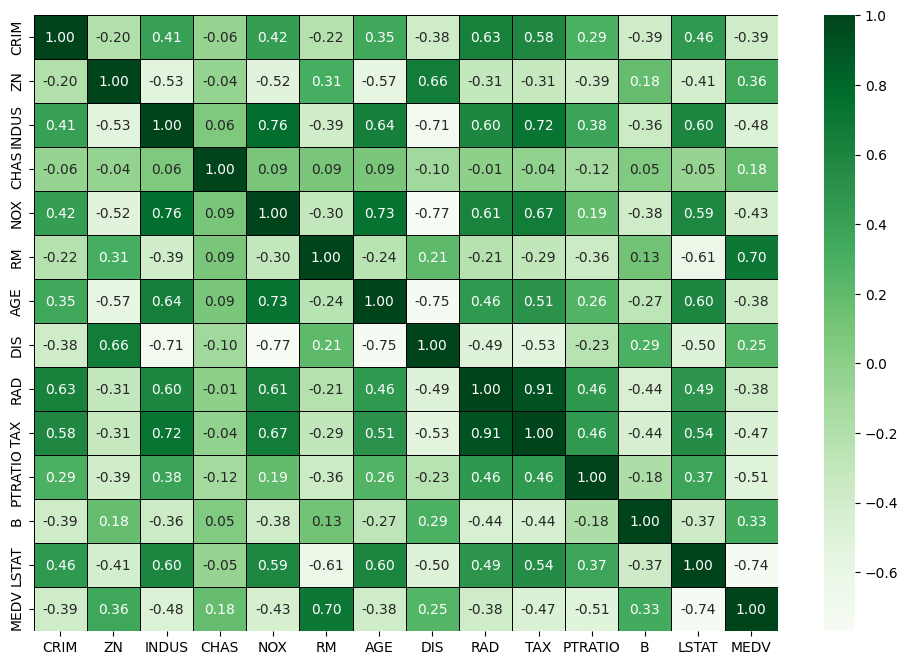

In [10]:
plt.figure(figsize=(12, 8))
fig = sns.heatmap(df.corr(), cmap='Greens', annot=True, linecolor="black", linewidths=0.5, fmt='.2f')

Histogram

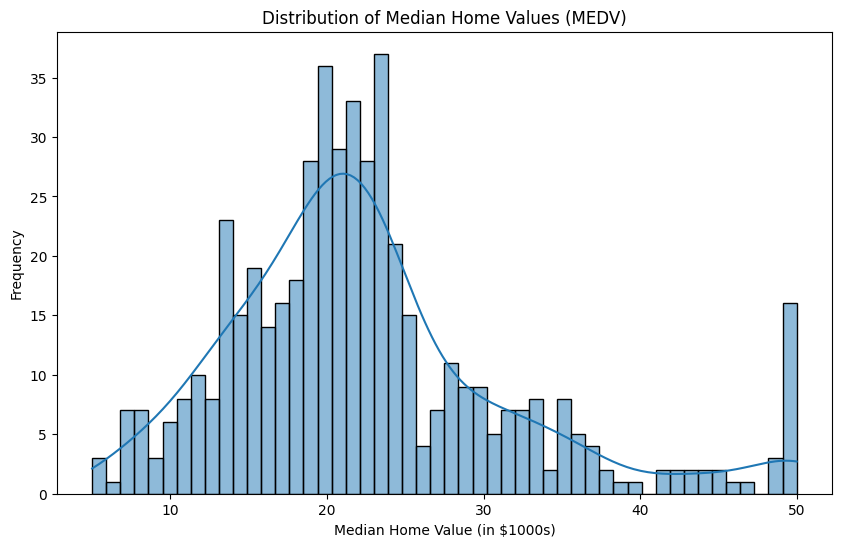

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(x='MEDV', data=df, bins=50, kde=True)
plt.title('Distribution of Median Home Values (MEDV)')
plt.xlabel('Median Home Value (in $1000s)')
plt.ylabel('Frequency')
plt.show()

Scatter Plot

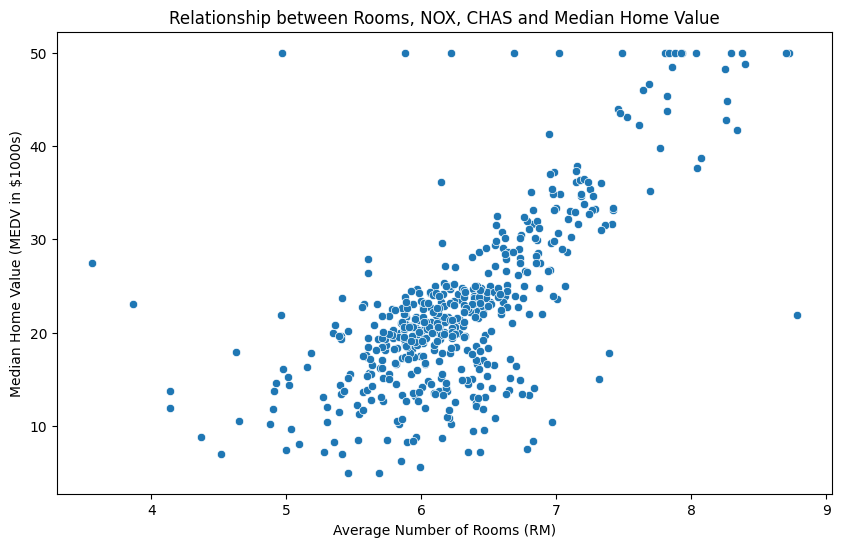

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='RM', y='MEDV', data=df)
plt.title('Relationship between Rooms, NOX, CHAS and Median Home Value')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median Home Value (MEDV in $1000s)')
plt.show()

Box Plot

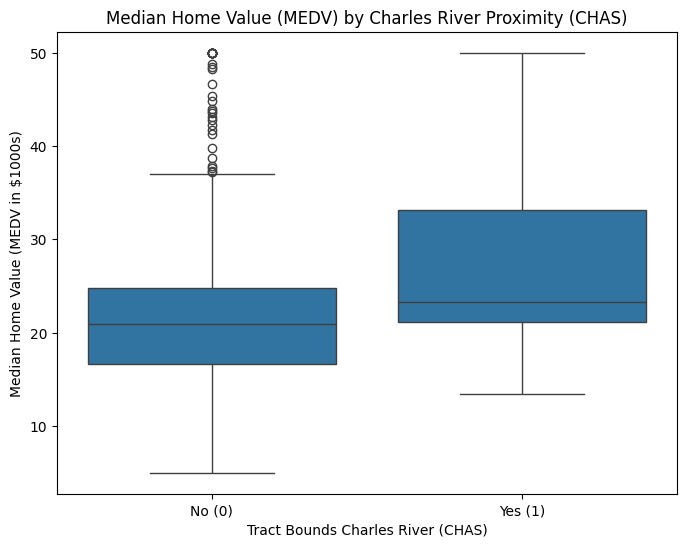

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='CHAS', y='MEDV', data=df)
plt.title('Median Home Value (MEDV) by Charles River Proximity (CHAS)')
plt.xlabel('Tract Bounds Charles River (CHAS)')
plt.ylabel('Median Home Value (MEDV in $1000s)')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.show()

<Axes: >

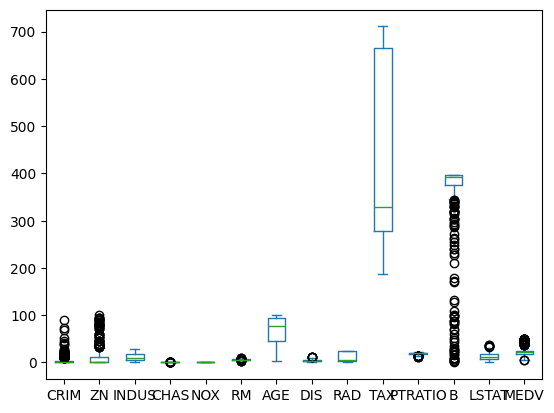

In [14]:
df.plot(kind='box') # pandas also be used to plot box plot

Bar Plot

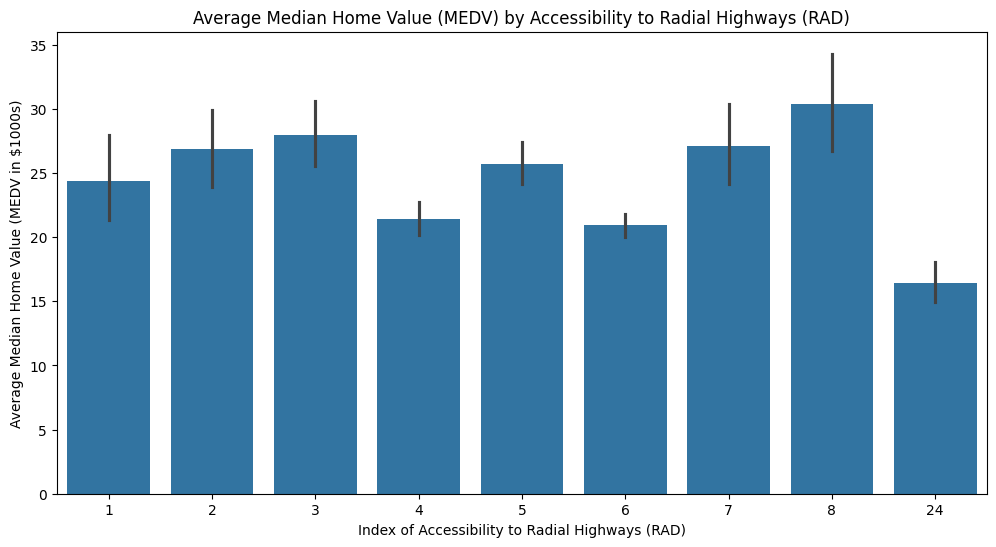

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(x='RAD', y='MEDV', data=df)
plt.title('Average Median Home Value (MEDV) by Accessibility to Radial Highways (RAD)')
plt.xlabel('Index of Accessibility to Radial Highways (RAD)')
plt.ylabel('Average Median Home Value (MEDV in $1000s)')
plt.show()

<Axes: >

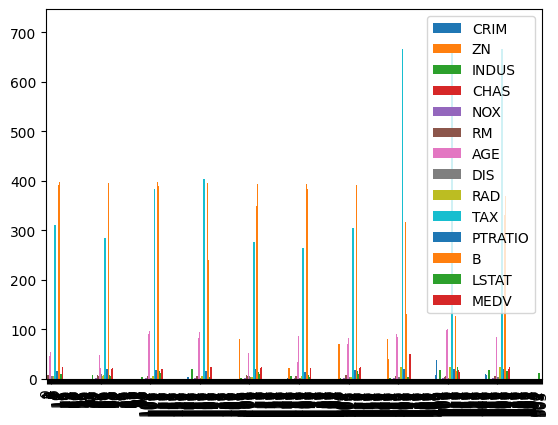

In [16]:
df.plot(kind='bar')

kind:
The kind of plot to produce:

‘line’ : line plot (default)

‘bar’ : vertical bar plot

‘barh’ : horizontal bar plot

‘hist’ : histogram

‘box’ : boxplot

‘kde’ : Kernel Density Estimation plot

‘density’ : same as ‘kde’

‘area’ : area plot

‘pie’ : pie plot

‘scatter’ : scatter plot (DataFrame only)

‘hexbin’ : hexbin plot (DataFrame only)

Pair Plot

In [17]:
# g = sns.pairplot(data=df)
# plt.show()

### **Feature Engg**

Feature selection

In [18]:
var_df = df[['RM', 'ZN', 'B', 'MEDV']]
var_df.head()

,RM,ZN,B,MEDV
0,6.575,18.0,396.90,24.0
1,6.421,0.0,396.90,21.6
2,7.185,0.0,392.83,34.7
3,6.998,0.0,394.63,33.4
4,7.147,0.0,396.90,36.2


In [19]:
var_df.corr()

,RM,ZN,B,MEDV
RM,1.000000,0.311991,0.128069,0.695360
ZN,0.311991,1.000000,0.175520,0.360445
B,0.128069,0.175520,1.000000,0.333461
MEDV,0.695360,0.360445,0.333461,1.000000


Train Test spilitting
+ 70-30
+ 80-20 --> default
+ 90-10 --> very small data

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
Y = df['MEDV'] # better use var_df
# var_df.drop('MEDV', axis=1, inplace=True) # or reassing to some variable if no use of inplace=true
X = df.drop('MEDV', axis=1)

In [22]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [232]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=32) # or train_size=0.7

In [233]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
170,1.20742,0.0,19.58,0,0.605,5.875,94.6,2.4259,5,403.0,14.7,292.29,14.43
273,0.22188,20.0,6.96,1,0.464,7.691,51.8,4.3665,3,223.0,18.6,390.77,6.58
383,7.99248,0.0,18.10,0,0.700,5.520,100.0,1.5331,24,666.0,20.2,396.90,24.56
32,1.38799,0.0,8.14,0,0.538,5.950,82.0,3.9900,4,307.0,21.0,232.60,27.71
470,4.34879,0.0,18.10,0,0.580,6.167,84.0,3.0334,24,666.0,20.2,396.90,16.29


Model selection

In [234]:
from sklearn.linear_model import LinearRegression # or LogisticRegression

In [235]:
model = LinearRegression()

Model Training

In [236]:
RM_train = X_train['RM']
RM_test = X_test['RM']

In [237]:
model.fit(RM_train.values.reshape(-1, 1), Y_train)

LinearRegression()

Predict label or model testing

In [238]:
RM_pred = model.predict(RM_test.values.reshape(-1, 1))

Model evaluation

In [239]:
from sklearn.metrics import mean_squared_error, r2_score

In [240]:
print("mse: ", mean_squared_error(Y_test, RM_pred))
print("r2 score: ", r2_score(Y_test, RM_pred))

mse:  53.87259362010938
r2 score:  0.4042099844395517


multiple linear regression

In [241]:
model.fit(X_train, Y_train)

LinearRegression()

In [242]:
Y_pred = model.predict(X_test)

In [243]:
print("mse: ", mean_squared_error(Y_test, Y_pred))
print("r2 score: ", r2_score(Y_test, Y_pred))

mse:  28.511283835745694
r2 score:  0.6846868305630168


polynomial regression

In [244]:
from sklearn.preprocessing import PolynomialFeatures
var = PolynomialFeatures(degree=2)

## Understanding `fit`, `transform`, and `fit_transform` in Scikit-Learn

In Scikit-Learn, the processes of fitting and transforming data are fundamental to machine learning workflows. Here’s a deeper look into each method:

### `fit()`
- The **`fit()`** method calculates the parameters needed by a transformer or model based on the training dataset. For example, with a scaler like `StandardScaler`, it computes the mean and standard deviation of the features.
- **Usage:** This method is primarily used when you only want to learn the parameters from the training set without transforming the data.
  
### `transform()`
- The **`transform()`** method takes the data and applies the parameters learned during the fitting process. Continuing with the `StandardScaler` example, it uses the mean and standard deviation from `fit()` to scale the training or test data.
- **Usage:** Use this method when you have a fitted model and want to transform existing datasets.

### `fit_transform()`
- The **`fit_transform()`** method combines both fitting and transforming into a single step. This is useful when you want to apply the transformation directly to your training data right after fitting.
- **Usage:** It is commonly used when processing the training set because it streamlines the process, reducing the amount of code you need to write.

### When to Use Each Method
| Method             | When to Use                                     | Key Point                                   |
|-------------------|------------------------------------------------|---------------------------------------------|
| `fit()`           | When you want only to compute parameters.      | No data transformation occurs.              |
| `transform()`     | When you have already fitted your model.       | Applies learned parameters to new data.    |
| `fit_transform()` | When you want to fit and transform simultaneously. | Convenient and efficient for training data.|

### Practical Example
Here's a practical illustration using `StandardScaler`:

```python
from sklearn.preprocessing import StandardScaler
import numpy as np

# Sample data
data = np.array([[1, 2], [2, 3], [3, 4]])

# Creating an instance of StandardScaler
scaler = StandardScaler()

# Using fit_transform for training data
scaled_data = scaler.fit_transform(data)

# Now, to transform new data
new_data = np.array([[4, 5], [5, 6]])
transformed_new_data = scaler.transform(new_data)
```

This example scales the training data before applying the same scaling parameters to new data points.

### Conclusion
Understanding how `fit()`, `transform()`, and `fit_transform()` work is crucial for building efficient machine learning pipelines and ensuring data is appropriately preprocessed. Each method serves specific purposes, so choosing the right one based on your workflow is essential for effective data handling.

In [245]:
poly_X_train = var.fit_transform(X_train)
poly_X_test = var.fit_transform(X_test)


In [246]:
model.fit(poly_X_train, Y_train)

LinearRegression()

In [247]:
poly_Y_pred = model.predict(poly_X_test)

In [248]:
print("mse: ", mean_squared_error(Y_test, poly_Y_pred))
print("r2 score: ", r2_score(Y_test, poly_Y_pred))

mse:  9.8897631130905
r2 score:  0.8906267227342493
